[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/JeremieJakubowicz/xhec-advanced-ai-2026/blob/main/Session2/Session2b-Going-Non-Local.ipynb)

# Session 2 (part B) — Going non-local: recurrent networks, and why it is hard

**Advanced AI: Language Models & Agents** · X-HEC · Fall 2026 · Author: Jérémie Jakubowicz

Part A replaced the lookup table by a convolutional network and won by a wide margin, with a model that reads nine tokens. But the clue for the next word is often further back: the name of the character speaking, the place, whether we are in a play or in a speech. This part gives the network a memory that reaches, in principle, all the way back to the start of the text, and then asks the honest question: **how far does it really reach, and why not further?**

**What you will take away from this part**

1. **Recurrence.** A state updated token by token gives a network an unbounded memory on paper. A plain recurrent network has it, and still loses to the local CNN.
2. **Vanishing gradients.** The reason: to learn that a distant token matters, the training signal must travel back through every step, and it shrinks at each one. The idea is right; the optimisation fails.
3. **The LSTM.** A recurrent network with gates, which let information (and gradient) pass through steps unchanged. It reaches further, uses it, and beats the CNN. It does not solve the problem, it pushes it back, and what remains is the reason for the next session.

In [ ]:
# On Google Colab, run this cell first, on a GPU runtime (Runtime > Change runtime type > T4 GPU).
# torch, pandas, matplotlib and scikit-learn are preinstalled there; tokenizers is not.
%pip install -q tokenizers

## 0. Setup: everything from part A, in one cell

Same corpus, splits, tokenizer and measurement as part A; same convolutional network, reloaded from its checkpoint as the model to beat.

In [2]:
import os, math, time, random, urllib.request, warnings
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import torch, torch.nn as nn, torch.nn.functional as F
from tokenizers import Tokenizer

BASE = "https://raw.githubusercontent.com/JeremieJakubowicz/xhec-advanced-ai-2026/main/"
def fetch(relative_path):
    local = os.path.basename(relative_path)
    if not os.path.exists(local):
        print("downloading", relative_path); urllib.request.urlretrieve(BASE + relative_path, local)
    return local

hugo = open(fetch("data/hugotexts.txt"), encoding="utf-8").read()
tok = Tokenizer.from_file(fetch("data/hugo_bpe_8k.json")); V = tok.get_vocab_size()
a, b = int(0.85 * len(hugo)), int(0.90 * len(hugo))
text = dict(train=hugo[:a], val=hugo[a:b], test=hugo[b:])
encode = lambda s: [i for j in range(0, len(s), 200_000) for i in tok.encode(s[j:j + 200_000]).ids]
data = {k: torch.tensor(encode(v)) for k, v in text.items()}
chars_per_token = {k: len(text[k]) / len(data[k]) for k in data}
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
TABLE_BITS_PER_CHAR = 2.02                                   # the smoothed table of part A, memory 2

def batch(split, n, length):
    d = data[split]; ix = torch.randint(0, len(d) - length - 1, (n,))
    return (torch.stack([d[i:i + length] for i in ix]).to(device), torch.stack([d[i + 1:i + length + 1] for i in ix]).to(device))

def surprise(model, split="test", window=128, warm=64, limit=None, batch_size=64):
    d = data[split][:limit]; starts = range(0, len(d) - window - 1, window - warm); model.eval(); nll, n = 0.0, 0
    with torch.no_grad():
        for b0 in range(0, len(starts), batch_size):
            idx = starts[b0:b0 + batch_size]
            x = torch.stack([d[i:i + window] for i in idx]).to(device); y = torch.stack([d[i + 1:i + window + 1] for i in idx]).to(device)
            losses = F.cross_entropy(model(x).reshape(-1, V), y.reshape(-1), reduction="none").reshape(len(idx), window)
            nll += losses[:, warm:].sum().item(); n += len(idx) * (window - warm)
    model.train(); return nll / n

def report(name, nats, split="test"):
    return dict(model=name, loss=round(nats, 3), perplexity=round(math.exp(nats), 1), bits_per_char=round(nats / math.log(2) / chars_per_token[split], 3))

def train(model, seconds, lr=2e-3, batch_size=64, window=128, log_every=250):
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.05)
    history, best, best_state, t0, step = [], float("inf"), None, time.time(), 0
    while time.time() - t0 < seconds:
        x, y = batch("train", batch_size, window)
        loss = F.cross_entropy(model(x).reshape(-1, V), y.reshape(-1))
        opt.zero_grad(set_to_none=True); loss.backward(); nn.utils.clip_grad_norm_(model.parameters(), 1.0); opt.step(); step += 1
        if step % log_every == 0:
            val = surprise(model, "val", limit=40_000); history.append((step, time.time() - t0, loss.item(), val))
            if val < best: best, best_state = val, {k: v.detach().clone() for k, v in model.state_dict().items()}
            print(f"step {step:5d}  {time.time() - t0:4.0f}s  train loss {loss.item():.3f}  val loss {val:.3f}")
    model.load_state_dict(best_state)
    return pd.DataFrame(history, columns=["step", "seconds", "train_loss", "val_loss"])

@torch.no_grad()
def generate(model, prompt, n=60, temperature=0.8, seed=0):
    g = torch.Generator(device="cpu").manual_seed(seed); ids = tok.encode(prompt).ids; model.eval()
    for _ in range(n):
        logits = model(torch.tensor([ids[-127:]]).to(device))[0, -1] / temperature
        ids.append(torch.multinomial(torch.softmax(logits, -1).cpu(), 1, generator=g).item())
    model.train(); return tok.decode(ids)

@torch.no_grad()
def context_curve(model, ks=(1, 2, 3, 4, 6, 8, 12, 16, 24, 32, 48, 64, 96, 128), n=600, K=128):
    torch.manual_seed(1); x, y = batch("test", n, K); out = {}; model.eval()
    for k in ks:
        nll = sum(F.cross_entropy(model(x[j:j + 200, K - k:])[:, -1], y[j:j + 200, -1], reduction="sum").item() for j in range(0, n, 200))
        out[k] = nll / n / math.log(2) / chars_per_token["test"]
    model.train(); return pd.Series(out, name="bits per char")

class LocalCNN(nn.Module):
    def __init__(self, d=256, layers=4, kernel=3, dropout=0.2):
        super().__init__(); self.emb = nn.Embedding(V, d); self.convs = nn.ModuleList([nn.Conv1d(d, 2 * d, kernel) for _ in range(layers)])
        self.norm, self.drop, self.kernel = nn.LayerNorm(d), nn.Dropout(dropout), kernel
        nn.init.normal_(self.emb.weight, std=d ** -0.5)
    def forward(self, x, emb=None):
        h = self.drop(self.emb(x) if emb is None else emb).transpose(1, 2)
        for conv in self.convs:
            u, g = conv(F.pad(h, (self.kernel - 1, 0))).chunk(2, dim=1); h = h + self.drop(u * torch.sigmoid(g))
        return self.norm(h.transpose(1, 2)) @ self.emb.weight.T

def load_checkpoint(model, name):
    state = torch.load(fetch(f"Session2/checkpoints/{name}.pt"), map_location="cpu")
    model.load_state_dict({k: v.float() for k, v in state.items()}); return model.to(device)

cnn = load_checkpoint(LocalCNN(), "cnn")
scoreboard = [report("smoothed table, memory 2", TABLE_BITS_PER_CHAR * math.log(2) * chars_per_token["test"]),
              report("local CNN (15 minutes)", surprise(cnn))]
curves = {"local CNN": context_curve(cnn)}
print(f"device: {device}"); pd.DataFrame(scoreboard)

device: mps


,model,loss,perplexity,bits_per_char
0,"smoothed table, memory 2",4.558,95.4,2.020
1,local CNN (15 minutes),3.944,51.6,1.748


## 1. The recurrent idea

A convolutional network computes the vector at position $t$ from a fixed window of inputs. A **recurrent** network computes it from the *previous vector* and the current token:

$$h_t = \tanh(W x_t + U h_{t-1} + b), \qquad p(\text{next token}) = \text{softmax}(h_t \cdot E^\top)$$

The state $h_t$ is a summary of everything read so far, updated one token at a time with the same small function. Since $h_t$ depends on $h_{t-1}$, which depends on $h_{t-2}$, and so on, the prediction at position $t$ depends, on paper, on the whole text before it: **an unbounded memory**, with no window to choose. The equation above is a *simple recurrent network* (Elman, 1990). Its code is three lines longer than the CNN's.

In [3]:
class Recurrent(nn.Module):
    """Embedding -> recurrent layers -> projection back to the embedding space -> one logit per token."""
    def __init__(self, kind="rnn", d=256, hidden=512, layers=2, dropout=0.3):
        super().__init__()
        self.emb, self.drop = nn.Embedding(V, d), nn.Dropout(dropout)
        cell = {"rnn": nn.RNN, "lstm": nn.LSTM}[kind]
        self.rnn = cell(d, hidden, layers, batch_first=True, dropout=dropout)     # h_t = f(h_{t-1}, x_t), stacked twice
        self.proj = nn.Linear(hidden, d)
        nn.init.normal_(self.emb.weight, std=d ** -0.5)

    def forward(self, x, emb=None):
        h, _ = self.rnn(self.drop(self.emb(x) if emb is None else emb))          # (batch, T, hidden), one state per position
        return self.proj(self.drop(h)) @ self.emb.weight.T

rnn = Recurrent("rnn").to(device)
print(f"{sum(p.numel() for p in rnn.parameters()) / 1e6:.1f} M parameters")
torch.manual_seed(0)
history_rnn = train(rnn, seconds=120, lr=1e-3)

3.1 M parameters


step   250    15s  train loss 5.210  val loss 5.315


step   500    31s  train loss 4.977  val loss 4.978


step   750    48s  train loss 4.669  val loss 4.801


step  1000    67s  train loss 4.679  val loss 4.665


step  1250    87s  train loss 4.422  val loss 4.586


step  1500   107s  train loss 4.394  val loss 4.524


In [4]:
rnn = load_checkpoint(Recurrent("rnn"), "rnn")                         # the same network, trained for fifteen minutes
scoreboard.append(report("simple RNN (15 minutes)", surprise(rnn)))
curves["simple RNN"] = context_curve(rnn)
pd.DataFrame(scoreboard)

,model,loss,perplexity,bits_per_char
0,"smoothed table, memory 2",4.558,95.4,2.020
1,local CNN (15 minutes),3.944,51.6,1.748
2,simple RNN (15 minutes),4.029,56.2,1.785


Same corpus, same tokens, same training budget, a memory that is unbounded instead of nine tokens: and the simple recurrent network **loses to the CNN**. The idea is right and the result is wrong. To see why, let us measure what the network actually does with its memory.

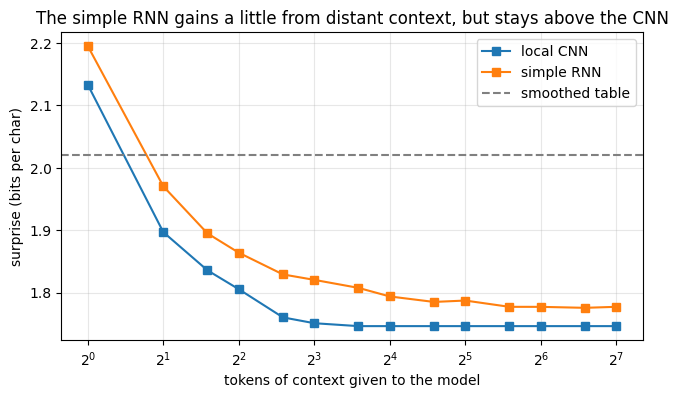

In [5]:
def plot_curves(curves, title):
    plt.figure(figsize=(7.5, 4))
    for name, c in curves.items():
        plt.plot(c.index, c.values, "s-", label=name)
    plt.axhline(TABLE_BITS_PER_CHAR, color="gray", ls="--", label="smoothed table")
    plt.xscale("log", base=2); plt.xlabel("tokens of context given to the model"); plt.ylabel("surprise (bits per char)")
    plt.grid(alpha=.3); plt.legend(); plt.title(title); plt.show()

plot_curves(curves, "The simple RNN gains a little from distant context, but stays above the CNN")

Two things in this figure. The RNN's curve keeps going down a little beyond nine tokens: it *does* use some distant context, which the CNN cannot. But at short context it is clearly worse than the CNN, and the gain from distance never makes up for it. In practice the network has learned a weak local model and a weaker long-range one. The next section explains why the second part fails.

## 2. Why it is hard: vanishing gradients

Training adjusts the weights in the direction that reduces the surprise. To learn that the token at distance $d$ matters for the current prediction, the gradient of the surprise must travel **back through $d$ steps** of the recurrence, and at each step it is multiplied by the derivative of $f$. With $\tanh$ and ordinary weights, that factor is smaller than 1 in most directions. Multiply $d$ factors smaller than 1 and you get, for $d = 100$, essentially zero: **the signal that a distant token mattered never reaches the weights.** The network could represent long-range dependencies; it never learns them.

**The formula.** Write $\mathcal{L}$ for the surprise at position $t$ and $z_k = W x_k + U h_{k-1} + b$ for the pre-activation, so that $h_k = \tanh(z_k)$. The chain rule through the recurrence gives, for the state $d$ steps back,

$$\frac{\partial \mathcal{L}}{\partial h_{t-d}} = \frac{\partial \mathcal{L}}{\partial h_t} \prod_{k = t-d+1}^{t} \frac{\partial h_k}{\partial h_{k-1}}, \qquad \frac{\partial h_k}{\partial h_{k-1}} = \mathrm{diag}\!\big(1 - h_k^2\big) \, U .$$

Each factor is the recurrent matrix $U$, scaled row by row by $1 - h_k^2 \in (0, 1]$, the derivative of $\tanh$. Bound the norm of every factor by a single number $\gamma = \|U\| \cdot \max_k \|1 - h_k^2\|_\infty$ and the product is bounded by a geometric sequence:

$$\left\| \frac{\partial \mathcal{L}}{\partial h_{t-d}} \right\| \le \left\| \frac{\partial \mathcal{L}}{\partial h_t} \right\| \, \gamma^{\,d} .$$

If $\gamma < 1$ the gradient **vanishes** exponentially with the distance; if the factors exceed 1 it **explodes**. With ordinary initialisations $\gamma$ is below 1, and the first case is the rule: on a log scale the gradient falls along a straight line of slope $\log \gamma$ per step, which is exactly the shape of the simple RNN's curve in the figure below. What that figure measures is the signal reaching the embedding of the token at distance $d$, $\partial \mathcal{L} / \partial x_{t-d} = (\partial \mathcal{L} / \partial h_{t-d}) \, \mathrm{diag}(1 - h_{t-d}^2) \, W$, which inherits the same decay. Finally, the update of $U$ is the sum over all distances of these contributions, so it is dominated by the last few tokens: this is the precise sense in which the network never learns to use the distant ones.

We can measure this directly. Take a fresh, untrained network, compute the surprise at the last position of a window, and look at the size of its gradient with respect to each input token, as a function of the distance to the last position.

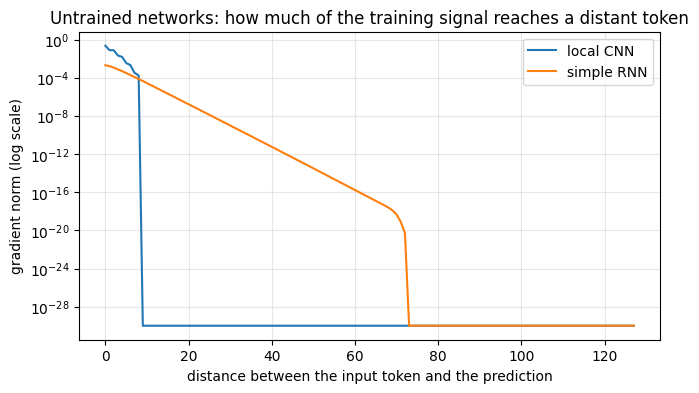

In [6]:
def gradient_by_distance(model, n=64, K=128):
    """Norm of d(surprise at the last position) / d(embedding of the token at distance d), averaged over n windows."""
    was_training = model.training; model.eval(); torch.manual_seed(2)
    x, y = batch("test", n, K)
    emb = model.emb(x).detach().requires_grad_(True)
    F.cross_entropy(model(x, emb=emb)[:, -1], y[:, -1]).backward()
    g = emb.grad.norm(dim=2).mean(dim=0).flip(0).cpu().numpy()        # index d = distance d from the last token
    model.zero_grad(set_to_none=True); model.train(was_training)
    return g

torch.manual_seed(0)
fresh = {"local CNN": LocalCNN().to(device), "simple RNN": Recurrent("rnn").to(device)}
plt.figure(figsize=(7.5, 4))
for name, m in fresh.items():
    plt.semilogy(gradient_by_distance(m) + 1e-30, label=name)
plt.xlabel("distance between the input token and the prediction"); plt.ylabel("gradient norm (log scale)")
plt.grid(alpha=.3); plt.legend(); plt.title("Untrained networks: how much of the training signal reaches a distant token"); plt.show()

Two regimes. The CNN's gradient is exactly zero beyond its window: nothing there can be learned, by design. The simple RNN's gradient decays exponentially: by distance 30 it is a million times smaller than at distance 0, by distance 80 it is numerically nothing. A token eighty positions back can matter as much as it wants: the training signal that would teach the network to use it never arrives.

(The mirror problem exists too: with weights a little larger, the factors are greater than 1 and the gradient *explodes*. That one is easy to contain, by clipping the gradient, which our training loop does. Vanishing is the hard one.)

## 3. The LSTM: a recurrent network with gates

The **Long Short-Term Memory** network (Hochreiter & Schmidhuber, 1997) is still a recurrent network: same interface, a state updated token by token by the same function. What changes is the function. The state is now made of two vectors of the same size: the **memory** $c_t$ (the *cell*), meant to survive many steps, and the **output** $h_t$, what the rest of the network sees, as before. At each step the network computes four vectors from the current token and the previous output, all of the same form as the single state of a simple RNN, each with its own weights:

$$v_t = \phi\big(W_v \, x_t + U_v \, h_{t-1} + b_v\big) \qquad \text{for } v \in \{\tilde c, f, i, o\}$$

| symbol       | $\phi$   | role                                                            | values    |
| ------------ | -------- | --------------------------------------------------------------- | --------- |
| $\tilde c_t$ | $\tanh$  | the **candidate**: what a simple RNN would write into its state | $(-1, 1)$ |
| $f_t$        | $\sigma$ | the **forget gate**: how much of the old memory to keep         | $(0, 1)$  |
| $i_t$        | $\sigma$ | the **input gate**: how much of the candidate to write          | $(0, 1)$  |
| $o_t$        | $\sigma$ | the **output gate**: how much of the memory to show             | $(0, 1)$  |

Then the memory is updated, and the output is read out of it:

$$c_t = \underbrace{f_t \odot c_{t-1}}_{\text{keep part of the old memory}} \;+\; \underbrace{i_t \odot \tilde{c}_t}_{\text{write part of the candidate}}, \qquad\qquad h_t = \underbrace{o_t \odot \tanh(c_t)}_{\text{show part of the memory}} .$$

The symbol $\odot$ is the coordinate-wise product: each coordinate of $c_t$ is a separate memory slot, with its own three gates. Read one slot. With $f = 1$ and $i = 0$ the slot is carried over unchanged, whatever the token says. With $f = 0$ and $i = 1$ it is overwritten by the candidate. In between, it is a weighted blend of the two, and the output gate decides how much of it the rest of the network gets to see. The simple RNN is the special case $f_t = 0$, $i_t = 1$, $o_t = 1$: then $c_t = \tilde c_t$ and, up to one extra $\tanh$, $h_t$ is Elman's state. Four sets of weights instead of one, which the parameter count of the next cell will show.

Now redo the computation of section 2 along the memory. Because the update of $c_t$ is **additive**, the derivative of $c_t$ with respect to $c_{t-1}$ is, up to the terms that go through the gates, the diagonal matrix of the forget gate: no $U$, no derivative of $\tanh$,

$$\frac{\partial c_t}{\partial c_{t-d}} \approx \prod_{k = t-d+1}^{t} \mathrm{diag}(f_k) .$$

The factor at each step is no longer a property of the weight matrix but a number in $(0, 1)$ that the network chooses, coordinate by coordinate, at every position. When the forget gate $f_t$ is close to 1, the memory passes through the step **unchanged**, and so does the gradient flowing back through it. Information can ride the memory across many steps, like a conveyor belt, until a gate decides to write or erase. The gates are a *knob* on the decay of the gradient, and the simple RNN has no such knob. Let us turn it by hand on a fresh network. PyTorch initialises the gate biases to 0, so $f_t \approx \sigma(0) = 1/2$: a fresh LSTM halves the signal at every step and loses it as fast as the simple RNN. Add a constant to $b_f$ to open the gate, and the signal travels the whole window undamped.

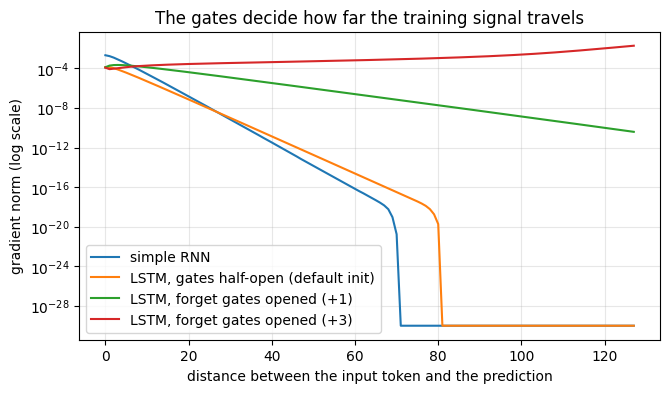

In [7]:
def open_forget_gates(model, bias):
    """Add `bias` to the forget-gate pre-activation of every LSTM layer (0 = PyTorch default, gates half-open)."""
    hidden = model.rnn.hidden_size
    for name, p in model.rnn.named_parameters():
        if "bias" in name:
            with torch.no_grad(): p[hidden:2 * hidden] += bias / 2                  # bias_ih and bias_hh both count
    return model

torch.manual_seed(0)
fresh = {"simple RNN": Recurrent("rnn").to(device),
         "LSTM, gates half-open (default init)": Recurrent("lstm").to(device),
         "LSTM, forget gates opened (+1)": open_forget_gates(Recurrent("lstm").to(device), 1.0),
         "LSTM, forget gates opened (+3)": open_forget_gates(Recurrent("lstm").to(device), 3.0)}
plt.figure(figsize=(7.5, 4))
for name, m in fresh.items():
    plt.semilogy(gradient_by_distance(m) + 1e-30, label=name)
plt.xlabel("distance between the input token and the prediction"); plt.ylabel("gradient norm (log scale)")
plt.grid(alpha=.3); plt.legend(); plt.title("The gates decide how far the training signal travels"); plt.show()

With the gates half-open the LSTM is no better than the simple RNN. With them open, the gradient at distance 127 is as large as at distance 0. Training does not set the gates by hand, of course; but it *can* move them, one weight at a time, wherever keeping information pays, and the next figure shows that it does. The simple RNN has nothing to move.

In [8]:
lstm = Recurrent("lstm").to(device)
print(f"{sum(p.numel() for p in lstm.parameters()) / 1e6:.1f} M parameters (the gates cost four times the weights of a simple RNN)")
torch.manual_seed(0)
history_lstm = train(lstm, seconds=120)

5.9 M parameters (the gates cost four times the weights of a simple RNN)


step   250    14s  train loss 5.131  val loss 5.258


step   500    28s  train loss 4.713  val loss 4.764


step   750    43s  train loss 4.345  val loss 4.502


step  1000    57s  train loss 4.280  val loss 4.325


step  1250    71s  train loss 3.985  val loss 4.208


step  1500    85s  train loss 3.927  val loss 4.137


step  1750    99s  train loss 3.840  val loss 4.055


step  2000   114s  train loss 3.804  val loss 3.983


In [9]:
lstm = load_checkpoint(Recurrent("lstm"), "lstm")                       # the same network, trained for fifteen minutes
scoreboard.append(report("LSTM (15 minutes)", surprise(lstm)))
curves["LSTM"] = context_curve(lstm)
pd.DataFrame(scoreboard)

,model,loss,perplexity,bits_per_char
0,"smoothed table, memory 2",4.558,95.4,2.020
1,local CNN (15 minutes),3.944,51.6,1.748
2,simple RNN (15 minutes),4.029,56.2,1.785
3,LSTM (15 minutes),3.759,42.9,1.666


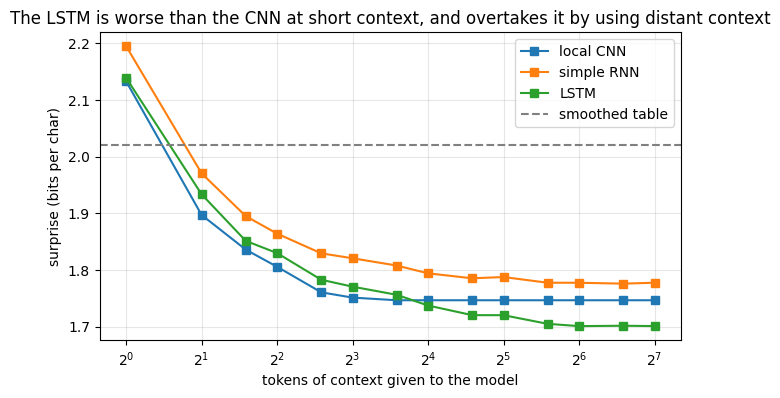

In [10]:
plot_curves(curves, "The LSTM is worse than the CNN at short context, and overtakes it by using distant context")

Read the LSTM's curve against the CNN's. With eight tokens of context or fewer, the CNN is the better model: it is the better *local* model. Past twenty tokens the LSTM overtakes it and keeps improving up to a hundred tokens of context, where the CNN stopped long ago. **The LSTM does not win by being a better local predictor; it wins by going to look for clues the CNN cannot see.** That is the whole point of recurrence, finally delivered.

### 3.1 Samples

In [11]:
for name, m in [("local CNN", cnn), ("simple RNN", rnn), ("LSTM", lstm)]:
    print(f"── {name} ──")
    for seed, prompt in enumerate(["L'amour est", "Les startups de l'IA sont"]):
        print(f"  {prompt!r} -> {generate(m, prompt, seed=seed).replace(chr(10), ' ')}")
    print()

── local CNN ──


  "L'amour est" -> L'amour est composée de la lune.  La première chose a été posée par le pertian, du dix-neuvième siècle, dont tout le monde n'a plus d'air pour ne pas mettre par un cadavre à la joie de sa vieille femme.  Pendant
  "Les startups de l'IA sont" -> Les startups de l'IA sont de la Renaissance, de toutes les maisons de Mayence, sa respiration de la fille de Cosette.  Il aperçut, avec un silence profond du lac le long du quai.  «Les faits généraux semblent avoir le chef de leur vage, le bas-empire,

── simple RNN ──


  "L'amour est" -> L'amour est d'abord au-dessus d'un deuil, Et, seul, au pier, l'aurore; On verra aux âmes dont tout le monde, L'aube, l'infini, Tirer à la vie, la vérité!  Oui.  


  "Les startups de l'IA sont" -> Les startups de l'IA sont de l'Isole.  La chambre de Mayence, sa consotte en 1830, et la société était d'une air d'excellence, il avait été encore eu à la marche humaine.  Quand le poète était étendu pour lui faire le bas d'assassin

── LSTM ──


  "L'amour est" -> L'amour est d'abord au retour du grand, Et, a l'heure où nous pommes, l'homme à l'autre s'éteint, J'avais un songe au fond de la brume, par un grand Accou, de sa vieille grotte noire où hab
  "Les startups de l'IA sont" -> Les startups de l'IA sont de l'Isole; C'est un bon, sa fortune publique et de la fille. La France, c'est son bon Dieu qui l'as trop égrat. Et nous travons tous les vents, et nous étions admirables, J'ai dit



## 4. Scoreboard, and what remains

The whole session in one table. Every model was tuned on the validation set and trained for the same fifteen minutes on the same corpus; only the architecture changes.

In [12]:
gain = {name: round(c[8] - c[128], 3) for name, c in curves.items()}          # bits per char gained from context beyond 8 tokens
summary = pd.DataFrame(scoreboard).set_index("model")
summary["parameters (M)"] = [None, 3.6, 3.1, 5.9]
summary["gain from context beyond 8 tokens"] = [0.0, gain["local CNN"], gain["simple RNN"], gain["LSTM"]]
summary

,loss,perplexity,bits_per_char,parameters (M),gain from context beyond 8 tokens
model,,,,,
"smoothed table, memory 2",4.558,95.4,2.020,NaN,0.000
local CNN (15 minutes),3.944,51.6,1.748,3.6,0.005
simple RNN (15 minutes),4.029,56.2,1.785,3.1,0.043
LSTM (15 minutes),3.759,42.9,1.666,5.9,0.070


Table < CNN < LSTM, as promised, with the simple RNN as the cautionary tale in between: an unbounded memory on paper is worth nothing if training cannot reach it. Three limits remain, and they are the agenda of the next session.

1. **The gradient still decays.** Slower than in the simple RNN, but the LSTM's curve flattens around a hundred tokens. A page is more than that.
2. **One step at a time.** The state at position $t$ needs the state at $t-1$: a recurrent network cannot process the positions of a text in parallel, while a convolution handles them all at once. Measure it yourself below: to read one text of 4,096 tokens, the CNN needs a few milliseconds, the LSTM tens of times more, and the gap widens with the length of the text. On the corpora of real language models, billions of tokens, this is the decisive constraint.
3. **A bottleneck.** Everything the model remembers must fit in one fixed-size vector, rewritten at every step. Whatever it decides to keep about the character introduced fifty tokens ago competes with everything since.

What if, instead of carrying a summary forward, every position could look **directly** at every earlier position, and learn *what* to look for? That mechanism is called **attention**, and it is the next session.

In [13]:
@torch.no_grad()
def forward_time(model, T, n=3):
    """Milliseconds to process one sequence of T tokens (forward pass only)."""
    sync = torch.cuda.synchronize if device.type == "cuda" else torch.mps.synchronize if device.type == "mps" else (lambda: None)
    model.eval(); x = torch.randint(0, V, (1, T), device=device); model(x); sync()
    t0 = time.time()
    for _ in range(n): model(x)
    sync(); model.train(); return (time.time() - t0) / n * 1000

pd.DataFrame({T: {name: forward_time(m, T) for name, m in [("local CNN", cnn), ("LSTM", lstm)]} for T in (256, 1024, 4096)}
             ).rename_axis(columns="tokens in the sequence").style.set_caption("milliseconds to read one sequence").format("{:.1f}")

tokens in the sequence,256,1024,4096
local CNN,1.0,1.2,3.6
LSTM,8.5,27.6,92.7


---
*Appendix: the hyperparameters.* Learning rates, dropout and sizes were chosen on the validation set with a search that is not part of this notebook; the notebook shows the winning values, and the checkpoints are the best validation weights of a fifteen-minute run. Elman (1990), *Finding Structure in Time*; Hochreiter & Schmidhuber (1997), *Long Short-Term Memory*; Pascanu, Mikolov & Bengio (2013), *On the difficulty of training recurrent neural networks*, for the vanishing and exploding gradients.